<h1>-------------------------------------------------</h1>
<h1>VI. Evaluation of quantile solar forecast quality</h1>
<h1>-------------------------------------------------</h1>

Like deterministic forecast, the quality of an ensemble forecast is the correspondence with corresponding observation. However, a probabilistic forecast contains more information than a detreministic one and the evaluation tools are more complex to handle. Firts, the quality of a probabilistic forecast relies on 2 fundamentals properties:
* Reliability (or calibration): Statistical consistency between
the forecasts and the observations (i.e. the nominal coverage
rate of the prediction intervals should be equal to the observed one)
* Resolution: It measures the capacity of a forecasting model to issue forecasts that are case-dependent.

Sharpness is also a very important feature of a probabilitic forecast. Users prefer to have sharp forecast (narrow prediction intervals). However, sharpness is not a quality indicator as it depends on the forecast itself (nà link with observations).

The verification tools proposed in this Jupyter Notebook where developed by the [laboratory PIMENT](https://piment.univ-reunion.fr/), University of La Reunion. They are detailed in the following article:

------
<i>Lauret, P., David, M., & Pinson, P. (2019). Verification of solar irradiance probabilistic forecasts. Solar Energy, 194, 254–271. https://doi.org/10.1016/j.solener.2019.10.041</i>


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import fsspec
import os

<h2>Load and read the data</h2>

The data used in this exercice have been generated with the preceding Jupyter Notebook ([link here](https://drive.google.com/file/d/1ngC1whkAzBfM96UanP1pBYKmiFRac2YE/view?usp=share_link)). We used two quantile forecast models (LMQR and XGBoost) to post-process the NWP deterministic forecast provided by the ECMWF. The NetCDF file containing the 2 probabilistic forecasts, the corresponding observations and the clear sky conditions, covering 6 month from July 1st to December 31st 2022. The forecast cover a single location, the Terre sainte campus in La Reunion, where high quality solar measurments are available (21.333°S, 51,483°E, 75m, UTC+4h).

In [2]:
from google.colab import drive
import os
drive.mount('/content/drive')
# print(os.listdir('/content/drive/MyDrive/')) # List files in the folder '/content/drive/MyDrive/'

# Read and display the file content
ds_prob = xr.open_dataset('/content/drive/MyDrive/lmqr_xgboost_1h.nc')
ds_prob

Mounted at /content/drive


<xarray.Dataset> Size: 43MB
Dimensions:      (step: 48, basetime: 4320, quantile: 11)
Coordinates:
  * step         (step) timedelta64[ns] 384B 01:00:00 ... 2 days 00:00:00
  * basetime     (basetime) datetime64[ns] 35kB 2022-07-01T01:00:00 ... 2022-...
  * quantile     (quantile) float64 88B 0.01 0.1 0.2 0.3 ... 0.7 0.8 0.9 0.99
Data variables:
    GHI_nwp      (step, basetime) float64 2MB ...
    GHI_lmqr     (basetime, step, quantile) float64 18MB ...
    GHI_meas     (step, basetime) float64 2MB ...
    GHI_clear    (step, basetime) float64 2MB ...
    zenith       (step, basetime) float64 2MB ...
    GHI_xgboost  (basetime, step, quantile) float64 18MB ...
Attributes:
    Title:         Probabilistic GHI forecasts generated
    Variables:     GHI_lmqr: probabilistic GHI forecasts generated with LMQR\...
    Units:         W/m**2
    Timestamping:  1-hour GHI, labeled right (end of interval)
    Horizon:       2 days
    Comment:       Training period: 2022-07-01T01 / 2022-11-04T00\nIndex rang...

<h2>Filtering of nigth GHI values</h2>

A specificity of solar irradiance is the intermittency between days and nights. Forecasting night values (no sun) is very simple and results in perfect precictions. It is thus important to not take into account for night values in the evaluation process. The zenith angle, which give the angle between the sun and the zenith, ranges between 0° and 90° during daytime. To remove zero night values of GHI, we filter the dataset with the zenith angle.

Below, we will only use the filtered dataset.

In [3]:
# Define solar zenith angle threshold
max_zenith = 90

# Create a filtered dataset ds_det_f
ds_prob_f = ds_prob.where(ds_prob['zenith'] <= max_zenith)

<h1>------------------------------------------------------</h1>
<h1>Section A: Reliability diagram and CRPS</h1>

<h2>Exercice 1: Evaluation of the reliability with the reliability diagram</h2>

The reliability diagram is a graphical verification display used to evaluate the reliability of the probabilistic forecasts. In this Jupyter Notebook, we follow the methodology defined by Pinson et al. [1] that is especially
designed for predictive distributions summarized by quantile forecasts. More precisely, quantile forecasts are reliable if their nominal proportions are equal to the proportions of the observed value. It means that, over an evaluation set of significant size, (statistically) the difference between observed and nominal probabilities should be as small as possible. Notice that for ensemble forecasts, the uniform CDF or non uniform CDF must be chosen before
applying this methodology [2].

This representation is attractive since the deviations from perfect reliability (i.e. the diagonal line) can be easily visualized. Nonetheless, due to the finite sample of pairs of observation/forecast and also due to possibly serial correlation in the sequence of forecasts and observations, it is possible that observed proportions are not exactly along the diagonal, even if the forecasts are perfectly reliable. In other words, reliability diagrams can be misinterpreted since even for perfectly reliable forecasts, deviations
from the ideal diagonal case can be observed.

------
[1] <i>Pinson, P., McSharry, P., & Madsen, H. (2010). Reliability diagrams for non-parametric density forecasts of continuous variables: Accounting for serial correlation. Quarterly Journal of the Royal Meteorological Society, 136(646), 77–90. https://doi.org/10.1002/qj.559
</i>

[2] <i>Lauret, P., David, M., & Pinson, P. (2019). Verification of solar irradiance probabilistic forecasts. Solar Energy, 194, 254–271. https://doi.org/10.1016/j.solener.2019.10.041</i>

------
<h3>Function to plot a reliability<h3>

In [4]:
def reliability_diag(fcst,tau,obs,s_title):
    ''' Plot reliability diagram of ensemble forecasts with consistency bars
    Brocker and Smith (2006), Increasing the Reliability of Reliability Diagrams
    Pinson et al. (2010), Reliability diagrams for non-parametric density forecasts
    of continuous variables: Accounting for serial correlation

    USAGE:
        obs_freq = reliability_diag(fcst,tau,obs,plot_title)

    INPUT:
        fcst: DataFrame with the ensemble members of size (steps,quantiles)
        tau: Dataframe with quantile probabilities of size (quantiles)
        obs: Dataframe of observations of size (steps)
        s_title: Title of the figure (string)

    OUTPUT:
        obs_freq: Dataframe with observed frequency for each quantile of size (1,quantiles)'''

    n,m = np.shape(fcst) # n: number of steps, m: number of quantiles
    fcst = np.sort(fcst, axis=1) # Sort quantile forecasts in ascending order

    # Count observed frequency
    obs_2D = np.repeat(obs,m,axis=1)
    obs_freq = np.zeros([1,m+2])
    obs_freq[:,-1] = 1
    obs_freq[:,1:-1] = np.sum(obs_2D < fcst, axis=0)/n

    tau = np.concat([0.0,tau,1.0], axis=None)
    df_obs_freq = pd.DataFrame(obs_freq, columns=tau)

    # Plotting
    plt.rcParams.update({'font.size': 10})
    plt.figure(figsize=[8, 3])
    plt.plot([0,1], [0,1], color='darkgrey', linestyle='-.', linewidth=1) # Ideal line
    plt.plot(tau, df_obs_freq.T, color='black', linestyle='-', linewidth=1.25)
    plt.title(s_title)
    plt.xlabel('Nominal proportion')
    plt.ylabel('Observed proportion')
    plt.grid()

    return df_obs_freq

<h3>Plot the reliability diagram of LMQR and XGBoost probabilistic forecasts</h3>

Use the function above to plot the reliability diagram for all the forecast/observation pairs of the 2 models:
* Gather all the forecast members (control forecast + perturbed forecasts) in a single DataFrame with
* Gather corresponding GHI observation in a single DataFrame
* Plot the rank histogram using the function rank_hist

Questions
* What are the meanings of the x (Nominal proportion) and y (Observed proportion) axis of the reliability diagram?
* Can we say that the LMQR and XGBoost are over or under-confident?
* Which model seems the most reliable?



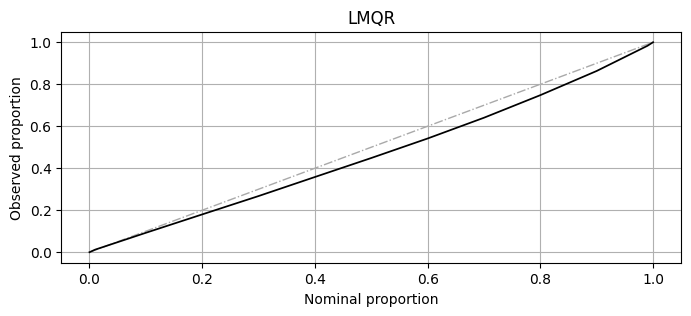

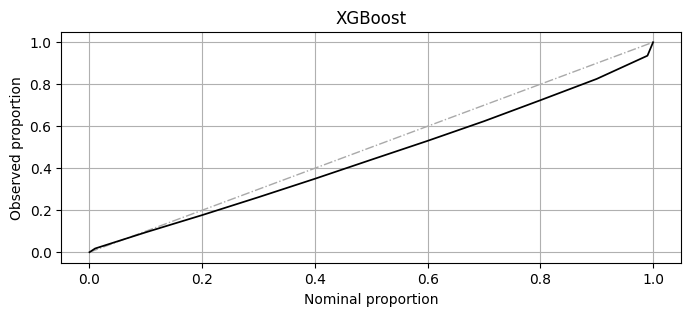

In [5]:
# Gather forecasts and observation in 2D DataFrame
df_obs = pd.DataFrame()
df_lmqr = pd.DataFrame()
df_xgboost = pd.DataFrame()
for i,st in enumerate(ds_prob_f.step):
  # Observations
  dum_obs = pd.DataFrame(ds_prob_f['GHI_meas'].sel(step=st).values)
  dum_obs = dum_obs.dropna() # Remove Nans
  df_obs = pd.concat([df_obs,dum_obs])
  # LMQR
  dum_lmqr = pd.DataFrame(ds_prob_f['GHI_lmqr'].sel(step=st).values)
  dum_lmqr = dum_lmqr.dropna() # Remove Nans
  df_lmqr = pd.concat([df_lmqr,dum_lmqr])
  # XGBoost
  dum_xgboost = pd.DataFrame(ds_prob_f['GHI_xgboost'].sel(step=st).values)
  dum_xgboost = dum_xgboost.dropna() # Remove Nans
  df_xgboost = pd.concat([df_xgboost,dum_xgboost])

# Quantile probabilities
df_tau = pd.DataFrame(ds_prob_f['quantile'])

# Plot the rank histograms
freq_lmqr = reliability_diag(df_lmqr,df_tau,df_obs,'LMQR')
freq_xgboost = reliability_diag(df_xgboost,df_tau,df_obs,'XGBoost')

<h2>Exercice 2: Evaluate the quality of the LMQR and XGBoost forecasts with the Continuous Rank Probability Score (CRPS)</h2>

Numerous metrics exist to evaluate the quality of probabilistic forecast (e.g. CRPS, pinball loss, ignorance score, interval score, etc.). However, the CRPS is the most used because it has several very intersting chacteristics:
* For deterministic forecast, the CRPS is equal to the MAE (Mean Absolute Error),
* The CRPS is a striclty proper score,
* The CRPS can be decomposed in reliability and the resolution.

The general formulation of the CRPS is:

$$CRPS = \frac{1}{N} \sum^N_{i=1} \int_{-\infty}^{+\infty} [\hat{F}_{fcst}^i - F_{obs}^i]^2 dx$$

where N is the number of forecast/observation pairs,  $\hat{F}_{fcst}$ the CDF of the forecast and $F_{obs}$ the CDF of the observation.

The decomposition of the CRPS gives:

$$CRPS = RELIABILITY - RESOLUTION + UNCERTAINTY$$

The uncertainty term cannot be modified by the forecast system and depends only on the observations variability.

A quantile forecast is a set of discrete quantile/probability pairs that approximates the observed CDF. Unlike Hersbach's method dedicated to ensemble forecasting [1] and based on a CDF with "steps" (probability jumps), the calculation of CRPS for quantile forecasts does not rely on any assumptions related to the shape of the CDF. Therefore, the computation of the CRPS for quantile forecast is to the integration of the Brier Score [2]. The Brier score is a proper score used to evaluate probabilistic forecasts of binary predictands
[3].

To our best knowledge, no library exists to compute the CRPS of quantile forecasts and its decomposition in relioability and resolution.

In the library of functions `crps_ur.py`, the function `crps_quantile_forecast` provides the computation and the decomposition of the CRPS for quantile forecats accordingly to Lauret et al. work [2].

-----
[1] <i>Hersbach, H. (2000). Decomposition of the Continuous Ranked Probability Score for Ensemble Prediction Systems. Weather and Forecasting, 15(5), 559–570. https://doi.org/10.1175/1520-0434(2000)015%253C0559:DOTCRP%253E2.0.CO;2
</i>

[2] <i>Lauret, P., David, M., & Pinson, P. (2019). Verification of solar irradiance probabilistic forecasts. Solar Energy, 194, 254–271. https://doi.org/10.1016/j.solener.2019.10.041</i>

[3] <i>Wilks, D. S. (2014). Statistical Methods in the Atmospheric Sciences An Introduction. Elsevier Science. http://public.eblib.com/choice/PublicFullRecord.aspx?p=269991</i>

-----
For this exercice:
* Compute the overall CRPS and its decomposition of the LMQR and XGBoost probabilistic forecats using the library `crps_quantile_forecast`
* Compute and plot the CRPS and relative CRPS along the lead time for the 2 forecasting models

Questions
* Wich model has the lowest CRPS?
* Do the values of the reliability of the two models correspond to the analysis of the reliability diagram?
* Which part of the decomposition has the greatest influence on the vale of the CRPS?

In [6]:
# Import the library crps_ur from GitHub (https://github.com/Laboratoire-Piment/Probabilistic_solar_forecast_lesson)
destination = "crps_ur.py"
fs = fsspec.filesystem("github", org="Laboratoire-Piment", repo="Probabilistic_solar_forecast_lesson")
fs.get("Jupyter_Notebooks/crps_ur.py", destination)

from crps_ur import crps_quantile_forecast

# print(os.listdir())

In [7]:
# Compute the overall CRPS and its decompostion using the fonction crps_quantile_forecast from the crps_ur library
# Warning: Computation time of the CRPS for quantile forecast (Brier score integration) depends on the number of
#          thresholds used to split the GHI space (last parameter of the function crps_quantile_forecast). Higer
#          the parameter, longer the computation time but also better the accuracy of the CRPS.

nb_thresholds = 30

df_crps_lmqr = crps_quantile_forecast(df_lmqr,df_tau,df_obs,nb_thresholds) # LMQR
print('---------------------------')
print('LMQR')
print(df_crps_lmqr)

df_crps_xgboost = crps_quantile_forecast(df_xgboost,df_tau,df_obs,nb_thresholds) # XGBoost
print('---------------------------')
print('XGBoost')
print(df_crps_xgboost)

---------------------------
LMQR
        CRPS  Reliability  Resolution  Uncertainty
0  69.450502     3.829037  116.651594   182.273058
---------------------------
XGBoost
        CRPS  Reliability  Resolution  Uncertainty
0  68.027416     4.851754  119.097395   182.273058


In [8]:
# Compute the CRPS for each lead time and probabilistic model

nb_thresholds = 10

# Pre-allocate DataFrames to store the results per lead time
crps_lmqr_st = pd.DataFrame(columns=['CRPS', 'Reliability' ,'Resolution' ,'Uncertainty'])
crps_xgboost_st = pd.DataFrame(columns=['CRPS', 'Reliability' ,'Resolution' ,'Uncertainty'])
avg_obs_st = pd.DataFrame(columns=['GHI_mean'])

# Cumulative probabilities of the quantiles
df_tau = pd.DataFrame(ds_prob_f['quantile'])

# Compute CRPS
for i,st in enumerate(ds_prob_f.step):
  # Observations
  dum_obs = pd.DataFrame(ds_prob_f['GHI_meas'].sel(step=st).values)
  dum_obs = dum_obs.dropna() # Remove Nans
  avg_obs_st = pd.concat([avg_obs_st,pd.DataFrame({'GHI_mean':dum_obs.mean()})])
  # LMQR Forecasts
  dum_fcst = pd.DataFrame(ds_prob_f['GHI_lmqr'].sel(step=st).values)
  dum_fcst = dum_fcst.dropna() # Remove Nans
  crps_lmqr_st = pd.concat([crps_lmqr_st,crps_quantile_forecast(dum_fcst,df_tau,dum_obs,nb_thresholds)]) # Compute CRPS
  # XGBoost Forecasts
  dum_fcst = pd.DataFrame(ds_prob_f['GHI_xgboost'].sel(step=st).values)
  dum_fcst = dum_fcst.dropna() # Remove Nans
  crps_xgboost_st = pd.concat([crps_xgboost_st,crps_quantile_forecast(dum_fcst,df_tau,dum_obs,nb_thresholds)]) # Compute CRPS

# Compute relative CRPS
crps_lmqr_st['Relative CRPS'] = crps_lmqr_st['CRPS']/avg_obs_st['GHI_mean']*100
crps_xgboost_st['Relative CRPS'] = crps_xgboost_st['CRPS']/avg_obs_st['GHI_mean']*100

# Index = step
avg_obs_st.index = np.arange(ds_prob_f.step.shape[0])+1
crps_lmqr_st.index = np.arange(ds_prob_f.step.shape[0])+1
crps_xgboost_st.index = np.arange(ds_prob_f.step.shape[0])+1

print('Finished')

Finished


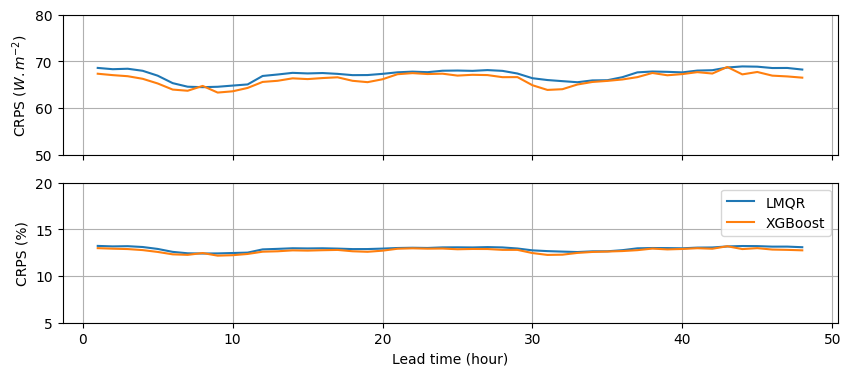

In [9]:
# Plot CRPS and relative CRPS along lead time

# Plotting
plt.rcParams.update({'font.size': 10}) # Set font size
fig, (ax1, ax2) = plt.subplots(2, sharex=True, figsize=(10, 4))
ax1.plot(crps_lmqr_st.index, crps_lmqr_st['CRPS'], label='LMQR')
ax1.plot(crps_xgboost_st.index, crps_xgboost_st['CRPS'], label='XGBoost')
ax1.set_ylabel('CRPS ($W.m^{-2}$)')
ax1.set_ylim([50,80])
ax1.grid()

ax2.plot(crps_lmqr_st.index, crps_lmqr_st['Relative CRPS'], label='LMQR')
ax2.plot(crps_xgboost_st.index, crps_xgboost_st['Relative CRPS'], label='XGBoost')
ax2.set_ylabel('CRPS (%)')
ax2.set_xlabel('Lead time (hour)')
ax2.set_ylim([5,20])
ax2.grid()
ax2.legend()

<h1>------------------------------------------------------</h1>
<h1>Section B: Comparison with reference models</h1>

Knowledge of quality indicators alone is insufficient to evaluate the performance of a forecasting model. Indeed, very simple models, such as persistence for deterministic forecasts, can yield excellent results. Therefore, a more complex model should outperform these simplistic models. In this section, we will we will compare our quantile forecats with two of the most widely used reference models in the field of solar forecasting.

<h2>Exercice B.1: GHI climatology</h2>

The climatology is the most common naive reference model used to benchmark probabilistic models in the field of meteorology. The predictive CDF is the observed past CDF of the GHI.

To build the climatology:
* Rank all measured GHI in ascending order
* Define the quantiles for the set of cumulative probabilities used previously (i.e. [1, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
* Generate the climatology forecast for all basetimes and setps
* Plot a sample of clear sky climatology forecasts

Questions
* Does the climatology change over time?
* What are the main drawbacks of such a forecasting model?

In [10]:
# Sort GHI measurements
ghi = np.sort(ds_prob_f['GHI_meas'].values.flatten())
ghi = ghi[~np.isnan(ghi)] # Remove Nans

# Define quantiles
tau = ds_prob_f['quantile'].values
idx_quantile = np.round(tau * (ghi.shape[0]-1)).astype(int)
ghi_quantile = ghi[idx_quantile]

# Generate Clear sky index climatology forecasts
ghi_clim = np.full([ds_prob_f.sizes['step'], ds_prob_f.sizes['basetime'],ds_prob_f.sizes['quantile']],np.nan)
for i,q in enumerate(ds_prob_f['quantile'].data):
  ghi_clim[:,:,i] = ghi_quantile[i]


# Create a filtered dataset ds_det_f
ds_prob_f['GHI_clim'] = ((['step', 'basetime', 'quantile'], ghi_clim))
ds_prob_f['GHI_clim'] = ds_prob_f['GHI_clim'].where(ds_prob_f['zenith'] <= max_zenith)

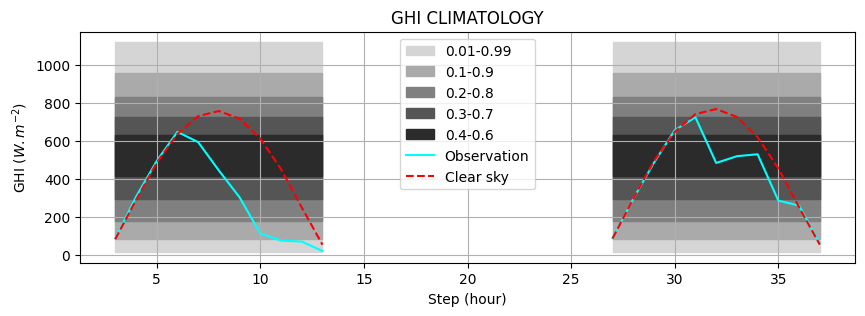

In [11]:
# Pick one basetime and plot a sample
bs = 600 # basetime = 3024, first basetime of the test set

fcst_prob = np.squeeze(ds_prob_f.isel(basetime=bs)[['GHI_clim']].to_array().values)
obs = ds_prob_f.isel(basetime=bs)[['GHI_meas']].to_array().values.T
cs = ds_prob_f.isel(basetime=bs)[['GHI_clear']].to_array().values.T
tau = ds_prob_f['quantile'].values
x = np.arange(ds_prob_f.step.count())+1

# Plotting
plt.rcParams.update({'font.size': 10})
plt.figure(figsize=[10, 3])
for q in np.arange(5):
    lab = str(tau[q]) + '-' + str(tau[10-q])
    plt.fill_between(x, fcst_prob[:,q], fcst_prob[:,10-q], color=str((5 - q) / 6), label=lab)
plt.plot(x, obs, '-', color='cyan', label='Observation')
plt.plot(x, cs, '--', color='red', label='Clear sky')
plt.ylabel('GHI ($W.m^{-2}$)')
plt.xlabel('Step (hour)')
plt.title('GHI CLIMATOLOGY')
plt.grid()
plt.legend()

<h2>Exercice B.2: Evaluate the quality of the GHI climatology</h2>

The first verification is to look a the calibration (or reliability) with the reliability diagram. Then, compute the CRPS and its decomposition.

Questions
* What can you conclude about the reliability of the climatology?
* Does the climatology have a good resolution? Why?
* Why a climatology model is an interesting reference forecast?

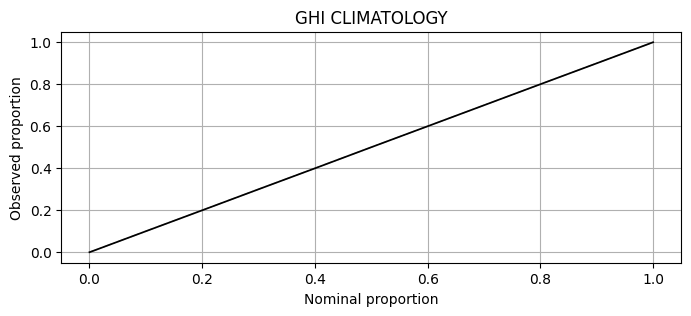

In [12]:
# Plot reliability diagram
# Gather forecasts and observation in 2D DataFrame
df_obs = pd.DataFrame()
df_clim = pd.DataFrame()
for i,st in enumerate(ds_prob_f.step):
  # Observations
  dum_obs = pd.DataFrame(ds_prob_f['GHI_meas'].sel(step=st).values)
  dum_obs = dum_obs.dropna() # Remove Nans
  df_obs = pd.concat([df_obs,dum_obs])
  # Climatology
  dum_clim = pd.DataFrame(ds_prob_f['GHI_clim'].sel(step=st).values)
  dum_clim = dum_clim.dropna() # Remove Nans
  df_clim = pd.concat([df_clim,dum_clim])

# Quantile probabilities
df_tau = pd.DataFrame(ds_prob_f['quantile'])

# Plot the rank histograms
freq_clim = reliability_diag(df_clim,df_tau,df_obs,'GHI CLIMATOLOGY')

In [13]:
# Compute the overall CRPS and its decompostion using the fonction crps_quantile_forecast from the crps_ur library
# Warning: Computation time of the CRPS for quantile forecast (Brier score integration) depends on the number of
#          thresholds used to split the GHI space (last parameter of the function crps_quantile_forecast). Higer
#          the parameter, longer the computation time but also better the accuracy of the CRPS.

nb_thresholds = 30

df_crps_clim = crps_quantile_forecast(df_clim,df_tau,df_obs,nb_thresholds)
print('---------------------------')
print('CSI climatology')
print(df_crps_clim)

---------------------------
CSI climatology
         CRPS  Reliability  Resolution  Uncertainty
0  183.107983     0.834925         0.0   182.273058


<h2>Exercice B.3: Clear sky index climatology</h2>

The clear sky index ($k_t^*$) is the ratio between GHI observations and corresponding clear sky GHI:
$$k_t^* = \frac{GHI_{measured}}{GHI_{clear sky}}$$

The clear sky index is widely used because it permits to remove the daily and seasonal trends of GHI time series. Then, the clear sky index time series is a very good proxy of the cloudiness.

The clear sky index climatology is an extremely simple reference probabilistic model. It assumes that the CDF of the quantile forecast is indentical to the CDF of past observations. To build the climatology:
* Compute the observed clear sky index
* Sort all the clear sky indices
* Define the quantiles for the set of cumulative probabilities used previously (i.e. [1, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])
* Generate the clear sky index climatology forecast for all basetimes and setps
* Plot a sample of clear sky climatology forecasts

Questions
* Do prediction intervals seem consistent with GHI observations?
* Does the clear sky climatology forecast change over time?
* Compared to the GHI climatology, what improvement brings the Clear sky index climatology?

In [14]:
# Compute clear sky index
ds_prob_f['CSI'] = ds_prob_f['GHI_meas']/ds_prob_f['GHI_clear']

# Sort clear sky indices
csi = np.sort(ds_prob_f['CSI'].values.flatten())
csi = csi[~np.isnan(csi)] # Remove Nans

# Define quantiles
tau = ds_prob_f['quantile'].values
idx_quantile = np.round(tau * (csi.shape[0]-1)).astype(int)
csi_quantile = csi[idx_quantile]

# Generate Clear sky index climatology forecasts
ghi_csi_clim = np.empty([ds_prob_f.sizes['step'], ds_prob_f.sizes['basetime'],ds_prob_f.sizes['quantile']])
for i,q in enumerate(ds_prob_f['quantile'].data):
  ghi_csi_clim[:,:,i] = ds_prob_f['GHI_clear']*csi_quantile[i]

ds_prob_f['GHI_csi_clim'] = ((['step', 'basetime', 'quantile'], ghi_csi_clim))

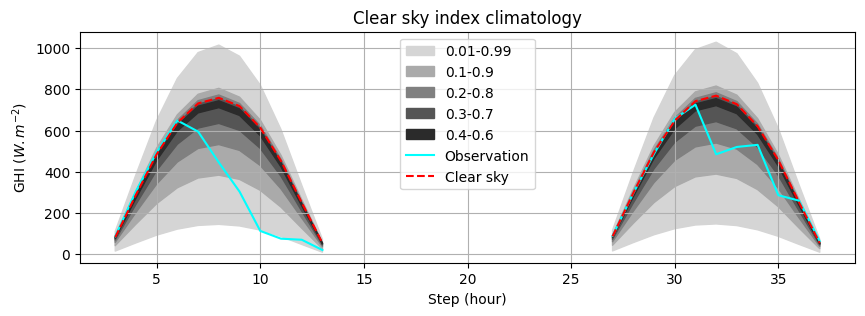

In [15]:
# Pick one basetime and plot a sample
bs = 600 # basetime = 3024, first basetime of the test set

fcst_prob = np.squeeze(ds_prob_f.isel(basetime=bs)[['GHI_csi_clim']].to_array().values)
obs = ds_prob_f.isel(basetime=bs)[['GHI_meas']].to_array().values.T
cs = ds_prob_f.isel(basetime=bs)[['GHI_clear']].to_array().values.T
x = np.arange(ds_prob_f.step.count())+1

# Plotting
plt.rcParams.update({'font.size': 10})
plt.figure(figsize=[10, 3])
for q in np.arange(5):
    lab = str(tau[q]) + '-' + str(tau[10-q])
    plt.fill_between(x, fcst_prob[:,q], fcst_prob[:,10-q], color=str((5 - q) / 6), label=lab)
plt.plot(x, obs, '-', color='cyan', label='Observation')
plt.plot(x, cs, '--', color='red', label='Clear sky')
plt.ylabel('GHI ($W.m^{-2}$)')
plt.xlabel('Step (hour)')
plt.title('Clear sky index climatology')
plt.grid()
plt.legend()


<h2>Exercice B.4: Evaluate the quality of the Clear sky index climatology</h2>

The first verification is to look a the calibration (or reliability) with the reliability diagram. Then, compute the CRPS and its decomposition.

Questions
* What can you conclude about the reliability of the Clear sky index climatology?
* Does the Clear sky index climatology have a good resolution? Why?
* Compared to the GHI climatology, why this model is more interesting?

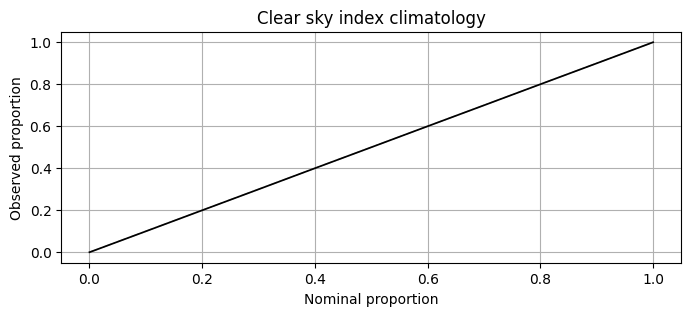

In [16]:
# Plot reliability diagram
# Gather forecasts and observation in 2D DataFrame
df_obs = pd.DataFrame()
df_csi_clim = pd.DataFrame()
for i,st in enumerate(ds_prob_f.step):
  # Observations
  dum_obs = pd.DataFrame(ds_prob_f['GHI_meas'].sel(step=st).values)
  dum_obs = dum_obs.dropna() # Remove Nans
  df_obs = pd.concat([df_obs,dum_obs])
  # CSI climatology
  dum_csi_clim = pd.DataFrame(ds_prob_f['GHI_csi_clim'].sel(step=st).values)
  dum_csi_clim = dum_csi_clim.dropna() # Remove Nans
  df_csi_clim = pd.concat([df_csi_clim,dum_csi_clim])

# Quantile probabilities
df_tau = pd.DataFrame(ds_prob_f['quantile'])

# Plot the rank histograms
freq_csi_clim = reliability_diag(df_csi_clim,df_tau,df_obs,'Clear sky index climatology')

In [17]:
# Compute the overall CRPS and its decompostion using the fonction crps_quantile_forecast from the crps_ur library
# Warning: Computation time of the CRPS for quantile forecast (Brier score integration) depends on the number of
#          thresholds used to split the GHI space (last parameter of the function crps_quantile_forecast). Higer
#          the parameter, longer the computation time but also better the accuracy of the CRPS.

nb_thresholds = 30

df_crps_csi_clim = crps_quantile_forecast(df_csi_clim,df_tau,df_obs,nb_thresholds)
print('---------------------------')
print('CSI climatology')
print(df_crps_csi_clim)

---------------------------
CSI climatology
        CRPS  Reliability  Resolution  Uncertainty
0  64.201562     3.479357  121.550853   182.273058


<h2>Exercice B.5: CSD-CLIM (Clear-Sky Dependent Climatology)</h2>

The CSD-CLIM [1] is another naive model built on the concept of climatology, i.e. based on the average statistical distribution of past observations. It is well known that for various cases (e.g. early morning, late evening), the clear-sky model alone, which is not the uncertain part of the forecast, permits to determine that GHI is limited to low-irradiance values. These considerations lead to the idea that $k_t^*$ and the clear-sky model should play a key role in the building of a benchmark model.

Therefore, the CSD-CLIM model exploits the deterministic variations of the clear-sky irradiance captured by the clear-sky model and proposes to bin the observed data according to the clear-sky irradiance values. The main goal of such a model is to discriminate the situations that the clear-sky model alone permits to separate. The CSD-CLIM is not totally naive because it has one parameter: the number of clear sky bins.

------
[1] <i>Le Gal La Salle, J., David, M., & Lauret, P. (2021). A new climatology reference model to benchmark probabilistic solar forecasts. Solar Energy, 223, 398–414. https://doi.org/10.1016/j.solener.2021.05.037</i>

------
To build the CSD-CLIM:
* Retrieve measured and clear sky irradiance
* Create a set of clear sky irradiance bins from
* Associate the bin number to all clear sky irradiance data
* Compute the CDF (quantiles with probabilities [1, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]) corresponding to each clear sky irradiance bin
* Generate the CSD-CLIM forecast for all basetimes and setps
* Plot a sample of clear sky climatology forecasts

Questions
* How the number of bins influence the shape of the predictve CDF?
* Why the CSD-CLIM prediction intervals are less smooth than the Clear sky index climatology?


In [18]:
cs_data = np.asarray(ds_prob_f['GHI_clear'].values)
obs_data = np.asarray(ds_prob_f['GHI_meas'].values)
# Quantile probabilities
df_tau = pd.DataFrame(ds_prob_f['quantile'])

# Define the clear sky irradiance bins
nbins = 30 # This is the unique parameter of the CSD-CLIM
cs_min = np.nanmin(cs_data)
cs_max = np.nanmax(cs_data)
bins = np.linspace(cs_min, cs_max+0.001, nbins + 1)

# Create a 2D arrays with the bins associated to clear sky irradiances
indices_bins = np.digitize(cs_data, bins)-1

# Compute CDF associated to each bin
CDF_csd_clim = np.empty([nbins, df_tau.shape[0]])
for i in range(nbins):
  subset = np.sort(obs_data[indices_bins == i])
  idx_quantile = np.round(df_tau * (subset.shape[0]-1)).astype(int)
  CDF_csd_clim[i,:] = subset[idx_quantile].transpose()

# Generate CSD-CLIM forecasts
GHI_csd_clim = np.full(shape=[ds_prob_f.sizes['step'],
                          ds_prob_f.sizes['basetime'],
                          ds_prob_f.sizes['quantile']], fill_value=np.nan)

for i in range(nbins):
  GHI_csd_clim[indices_bins == i,:] = CDF_csd_clim[i]

ds_prob_f['GHI_csd_clim'] = ((['step', 'basetime', 'quantile'], GHI_csd_clim))

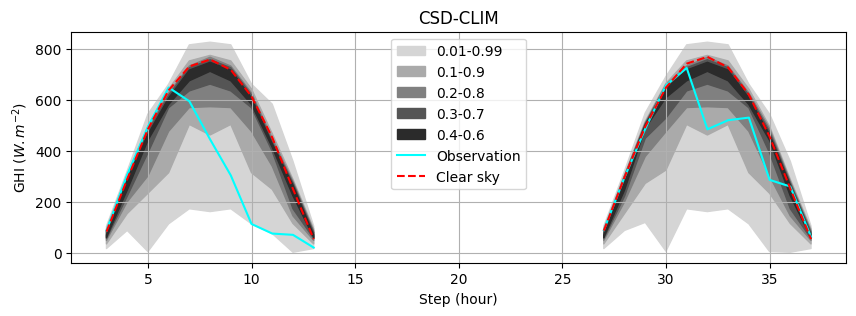

In [20]:
# Pick one basetime and plot a sample
bs = 600 # basetime = 3024, first basetime of the test set

fcst_prob = np.squeeze(ds_prob_f.isel(basetime=bs)[['GHI_csd_clim']].to_array().values)
obs = ds_prob_f.isel(basetime=bs)[['GHI_meas']].to_array().values.T
cs = ds_prob_f.isel(basetime=bs)[['GHI_clear']].to_array().values.T
tau = ds_prob_f['quantile'].values
x = np.arange(ds_prob_f.step.count())+1

# Plotting
plt.rcParams.update({'font.size': 10})
plt.figure(figsize=[10, 3])
for q in np.arange(5):
    lab = str(tau[q]) + '-' + str(tau[10-q])
    plt.fill_between(x, fcst_prob[:,q], fcst_prob[:,10-q], color=str((5 - q) / 6), label=lab)
plt.plot(x, obs, '-', color='cyan', label='Observation')
plt.plot(x, cs, '--', color='red', label='Clear sky')
plt.ylabel('GHI ($W.m^{-2}$)')
plt.xlabel('Step (hour)')
plt.title('CSD-CLIM')
plt.grid()
plt.legend()

<h2>Exercice B.6: Evaluate the quality of the CSD-CLIM</h2>

The first verification is to look a the calibration (or reliability) with the reliability diagram. Then, compute the CRPS and its decomposition.

Questions
* Does the CSD-CLIM conserve the perfect reliability proprety of climatology forecasts?
* Does the CSD-CLIM have a better resolution than the Clear sky index climatology? Why?

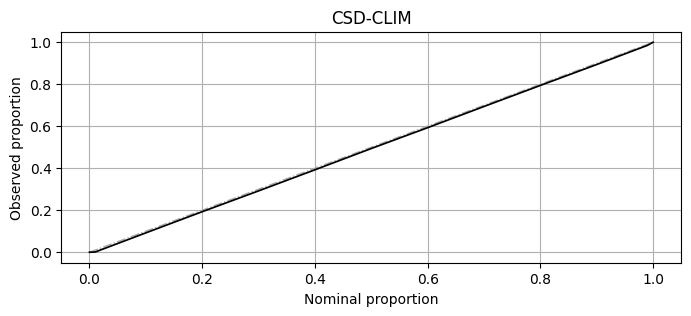

In [21]:
# Plot reliability diagram
# Gather forecasts and observation in 2D DataFrame
df_obs = pd.DataFrame()
df_csd_clim = pd.DataFrame()
for i,st in enumerate(ds_prob_f.step):
  # Observations
  dum_obs = pd.DataFrame(ds_prob_f['GHI_meas'].sel(step=st).values)
  dum_obs = dum_obs.dropna() # Remove Nans
  df_obs = pd.concat([df_obs,dum_obs])
  # CSD-CLIM
  dum_csd_clim = pd.DataFrame(ds_prob_f['GHI_csd_clim'].sel(step=st).values)
  dum_csd_clim = dum_csd_clim.dropna() # Remove Nans
  df_csd_clim = pd.concat([df_csd_clim,dum_csd_clim])

# Quantile probabilities
df_tau = pd.DataFrame(ds_prob_f['quantile'])

# Plot the rank histograms
freq_csd_clim = reliability_diag(df_csd_clim,df_tau,df_obs,'CSD-CLIM')

In [22]:
# Compute the overall CRPS and its decompostion using the fonction crps_quantile_forecast from the crps_ur library
# Warning: Computation time of the CRPS for quantile forecast (Brier score integration) depends on the number of
#          thresholds used to split the GHI space (last parameter of the function crps_quantile_forecast). Higer
#          the parameter, longer the computation time but also better the accuracy of the CRPS.

nb_thresholds = 30

df_crps_csd_clim = crps_quantile_forecast(df_csd_clim,df_tau,df_obs,nb_thresholds)
print('---------------------------')
print('CSD-CLIM')
print(df_crps_csd_clim)

---------------------------
CSD-CLIM
        CRPS  Reliability  Resolution  Uncertainty
0  63.048948      2.08512  121.309231   182.273058


<h2>Exercice B.7: Benchmark of the LMQR and XGBoost forecast with the reference models</h2>

In this last exercice, the aim is to compare the quality of the LMQR and XGBoost forecasting models with the 3 reference models:
* Using bar charts, plot the CRPS and its decomposition for all the forecasting models used in this Jupyter Notebook

Questions
* What can you conclude on the quality of LMQR and XGBoost models?
* Are these results fair?

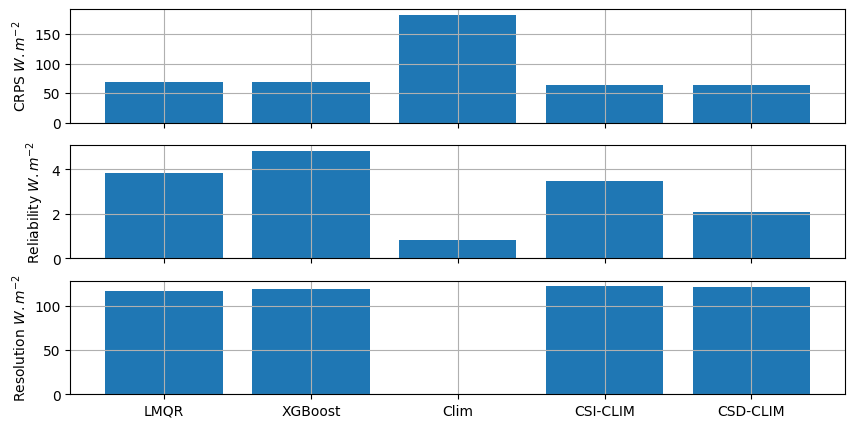

In [23]:
# Plot CRPS and its decomposition for all the models
plt.rcParams.update({'font.size': 10})
fig, (ax1, ax2, ax3) = plt.subplots(3, sharex=True, figsize=(10, 5))
x = np.array(['LMQR', 'XGBoost', 'Clim', 'CSI-CLIM', 'CSD-CLIM'])

# CRPS
y = np.array([df_crps_lmqr['CRPS'], df_crps_xgboost['CRPS'],
             df_crps_clim['CRPS'], df_crps_csi_clim['CRPS'],
             df_crps_csd_clim['CRPS']]).flatten()
ax1.bar(x,y)
ax1.set_ylabel('CRPS $W.m^{-2}$')
ax1.grid()

# Reliability
y = np.array([df_crps_lmqr['Reliability'], df_crps_xgboost['Reliability'],
             df_crps_clim['Reliability'], df_crps_csi_clim['Reliability'],
             df_crps_csd_clim['Reliability']]).flatten()
ax2.bar(x,y)
ax2.set_ylabel('Reliability $W.m^{-2}$')
ax2.grid()

# Resolution
y = np.array([df_crps_lmqr['Resolution'], df_crps_xgboost['Resolution'],
             df_crps_clim['Resolution'], df_crps_csi_clim['Resolution'],
             df_crps_csd_clim['Resolution']]).flatten()
ax3.bar(x,y)
ax3.set_ylabel('Resolution $W.m^{-2}$')
ax3.grid()